<a href="https://colab.research.google.com/github/Malek720/MachineLearning/blob/main/Adult_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Chargement des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Noms des colonnes selon la documentation UCI
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# Chargement de adult.data
df_train = pd.read_csv('adult.data', header=None, names=columns, na_values=' ?', skipinitialspace=True)

# Chargement de adult.test (en ignorant la première ligne de commentaire si présente)
df_test = pd.read_csv('adult.test', header=None, names=columns, na_values=' ?', skipinitialspace=True, skiprows=1)

# Nettoyage du point final présent dans la colonne income de adult.test (ex: '>50K.' -> '>50K')
df_test['income'] = df_test['income'].str.rstrip('.')

# Fusion temporaire pour la phase d'exploration et de préparation
df = pd.concat([df_train, df_test], ignore_index=True)
print("Forme du dataset global :", df.shape)
df.head()

Forme du dataset global : (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Étape 1 : Inspection générale de la structure

In [2]:
# 1. Informations générales sur les types de colonnes et valeurs non nulles
print("--- Informations sur le Dataset ---")
df.info()

# 2. Vérification des premières lignes
print("\n--- Aperçu des données ---")
df.head()

# 3. Détection des doublons stricts
print("\nNombre de lignes doublons :", df.duplicated().sum())

# 4. Décompte des valeurs manquantes '?' par colonne
missing_values = (df == '?').sum()
print("\n--- Valeurs manquantes ('?') par colonne ---")
print(missing_values[missing_values > 0])

--- Informations sur le Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

--- Aperçu des données ---

Nombre de lignes doublons : 

Étape 2 : Statistique descriptive (Numérique & Catégorielle)

In [3]:
# Statistiques pour les variables numériques
print("--- Statistiques des variables numériques ---")
df.describe().T

# Statistiques pour les variables catégorielles
print("\n--- Statistiques des variables catégorielles ---")
df.describe(include=['object', 'category']).T

--- Statistiques des variables numériques ---

--- Statistiques des variables catégorielles ---


,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital_status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
sex,48842,2,Male,32650
native_country,48842,42,United-States,43832
income,48842,2,<=50K,37155


Étape 3 : Visualisation des distributions et des relations

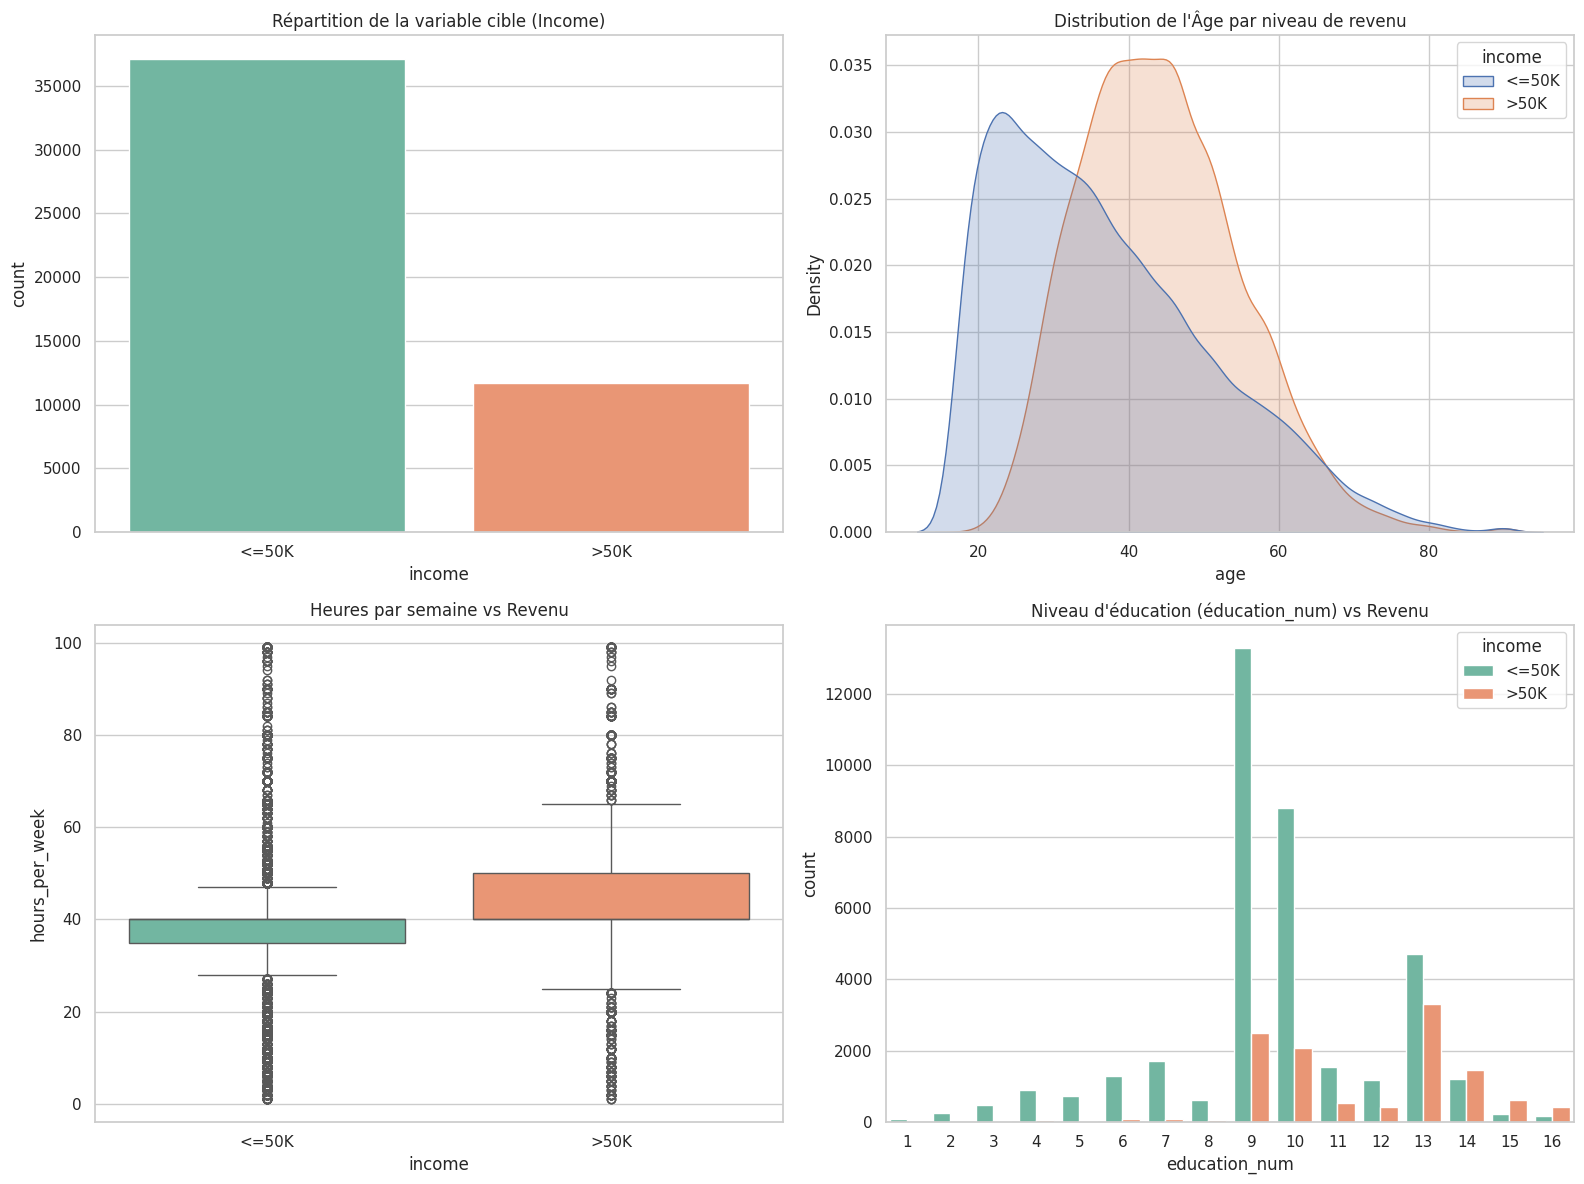

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration du style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Distribution de la variable cible 'income'
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='income', hue='income', palette='Set2', legend=False)
plt.title("Répartition de la variable cible (Income)")

# 2. Distribution de l'âge selon le niveau de revenu
plt.subplot(2, 2, 2)
sns.kdeplot(data=df, x='age', hue='income', common_norm=False, fill=True)
plt.title("Distribution de l'Âge par niveau de revenu")

# 3. Heures travaillées par semaine selon le revenu
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='income', y='hours_per_week', hue='income', palette='Set2', legend=False)
plt.title("Heures par semaine vs Revenu")

# 4. Niveau d'éducation (education_num) vs Revenu
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='education_num', hue='income', palette='Set2')
plt.title("Niveau d'éducation (éducation_num) vs Revenu")

plt.tight_layout()
plt.show()

Phase 2 : Nettoyage et Transformation des données

In [5]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Copie de travail propre
df_prep = df.copy()

# Replace '?' par NaN pour faciliter le traitement par scikit-learn / pandas
df_prep.replace('?', np.nan, inplace=True)

# 2. Nettoyage des lignes et suppression des colonnes redondantes/inutiles
# - 'fnlwgt' : poids démographique échantillonnal, n'a pas de pouvoir prédictif direct sur le statut individuel.
# - 'education' : redondant avec 'education_num' (qui est déjà une version ordonnée numérique).
df_prep.drop(columns=['fnlwgt', 'education'], inplace=True, errors='ignore')

# 3. Traitement des valeurs manquantes (Imputation)
# Justification : Pour les variables catégorielles ('workclass', 'occupation', 'native_country'),
# l'imputation par la mode (valeur la plus fréquente) évite la perte inutile d'observations.
cat_cols_missing = ['workclass', 'occupation', 'native_country']
for col in cat_cols_missing:
    df_prep[col].fillna(df_prep[col].mode()[0], inplace=True)

# 4. Feature Engineering (Création de nouvelles variables pertinentes)
# Justification : Les variables 'capital_gain' et 'capital_loss' sont très creuses (beaucoup de 0).
# Combiner ces deux variables en un 'net_capital' résume le bilan financier net de l'individu.
df_prep['net_capital'] = df_prep['capital_gain'] - df_prep['capital_loss']

# Regroupement des modalités rares dans 'native_country' (Exemple: US vs Non-US ou par région)
# Justification : 'native_country' a une cardinalité élevée avec > 90% d'individus provenant des US.
df_prep['is_native_us'] = (df_prep['native_country'] == 'United-States').astype(int)
df_prep.drop(columns=['native_country'], inplace=True)

# 5. Encodage de la variable cible 'income'
# '<=50K' -> 0, '>50K' -> 1
df_prep['income'] = df_prep['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# 6. Séparation des features (X) et de la cible (y)
X = df_prep.drop(columns=['income'])
y = df_prep['income']

# Identification des colonnes numériques et catégorielles restantes
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables numériques :", num_features)
print("Variables catégorielles :", cat_features)

Variables numériques : ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'net_capital', 'is_native_us']
Variables catégorielles : ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']


/tmp/ipykernel_2314/2892173803.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_prep[col].fillna(df_prep[col].mode()[0], inplace=True)


Pipeline de Transformation & Standardisation


In [7]:
# Définition des transformateurs :
# - Numérique : StandardScaler (centrage-réduction obligatoire pour K-Means, SVM, KNN, Reg. Logistique)
# - Catégorielle : OneHotEncoder (pour les algorithmes ne gérant pas le texte brut)

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Application des transformations
X_prepared = preprocessor.fit_transform(X)

# Récupération des noms de colonnes transformées
encoded_cat_cols = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features)
all_feature_names = num_features + list(encoded_cat_cols)

# Reconstitution d'un DataFrame propre et préparé
df_cleaned_prepared = pd.DataFrame(X_prepared, columns=all_feature_names)
df_cleaned_prepared['income'] = y.values

print("Taille du dataset nettoyé et préparé :", df_cleaned_prepared.shape)
df_cleaned_prepared.head()

Taille du dataset nettoyé et préparé : (48842, 44)


,age,education_num,capital_gain,capital_loss,hours_per_week,net_capital,is_native_us,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,income
0,0.025996,1.136512,0.146932,-0.217127,-0.034087,0.158175,0.304846,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0
1,0.828308,1.136512,-0.144804,-0.217127,-2.213032,-0.132642,0.304846,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0
2,-0.046942,-0.419335,-0.144804,-0.217127,-0.034087,-0.132642,0.304846,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0
3,1.047121,-1.197259,-0.144804,-0.217127,-0.034087,-0.132642,0.304846,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0
4,-0.776316,1.136512,-0.144804,-0.217127,-0.034087,-0.132642,-3.280344,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0


Export du fichier nettoyé (Livrable requis)

In [8]:
# Sauvegarde en CSV
df_cleaned_prepared.to_csv('adult_cleaned_prepared.csv', index=False)

# Téléchargement automatique vers votre machine locale via Colab
from google.colab import files
files.download('adult_cleaned_prepared.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Étape 3 : Segmentation (Clustering par K-Means)

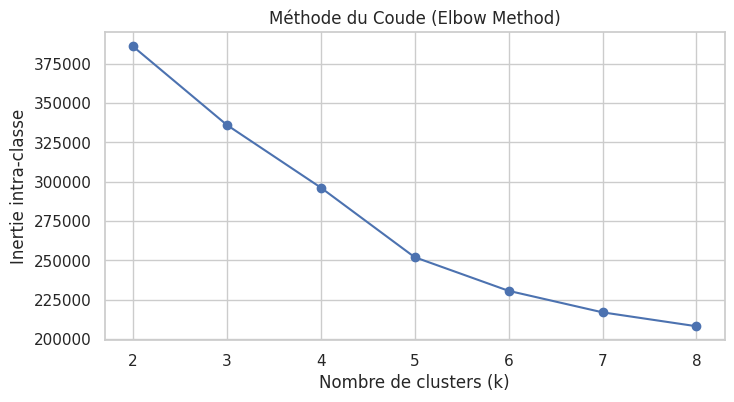

Silhouette Score (k=3) : 0.3386

--- Profil moyen des individus par Cluster ---


,age,education_num,hours_per_week,capital_gain
cluster,,,,
0,38.659559,10.163833,40.400832,592.960526
1,38.002175,8.983084,40.061141,469.076849
2,46.610656,13.024590,50.475410,99999.000000


In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Sélection des features préparées (sans la variable cible 'income')
X_clustering = df_cleaned_prepared.drop(columns=['income'])

# Pour accélérer le calcul sur un large dataset, on peut utiliser un sous-échantillon pour le Silhouette Score
X_sample = X_clustering.sample(n=5000, random_state=42)

# 2. Recherche du nombre optimal de clusters k (Méthode du coude)
inertia = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    inertia.append(kmeans.inertia_)

# Visualisation du graphique du coude
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie intra-classe')
plt.title('Méthode du Coude (Elbow Method)')
plt.grid(True)
plt.show()

# 3. Entraînement du modèle final (par exemple avec k=3 ou k=4 selon le coude)
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_cleaned_prepared['cluster'] = kmeans_final.fit_predict(X_clustering)

# Score de Silhouette sur l'échantillon
sil_score = silhouette_score(X_sample, kmeans_final.predict(X_sample))
print(f"Silhouette Score (k={k_optimal}) : {sil_score:.4f}")

# 4. Interprétation des clusters
# Analyse des moyennes par cluster sur les variables d'origine
df_analysis = df.copy()
df_analysis['cluster'] = df_cleaned_prepared['cluster']

print("\n--- Profil moyen des individus par Cluster ---")
df_analysis.groupby('cluster')[['age', 'education_num', 'hours_per_week', 'capital_gain']].mean()

Étape 4 : Classification (Prédiction du revenu $> 50\text{K}$)

=== Régression Logistique ===
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7431
           1       0.73      0.60      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.80      0.76      0.78      9769
weighted avg       0.84      0.85      0.85      9769

ROC-AUC Score : 0.9037

=== Arbre de Décision ===
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      7431
           1       0.79      0.58      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.76      0.79      9769
weighted avg       0.86      0.86      0.85      9769

ROC-AUC Score : 0.9014

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      7431
           1       0.82      0.57      0.67      2338

    accuracy                           0.87      9769
  

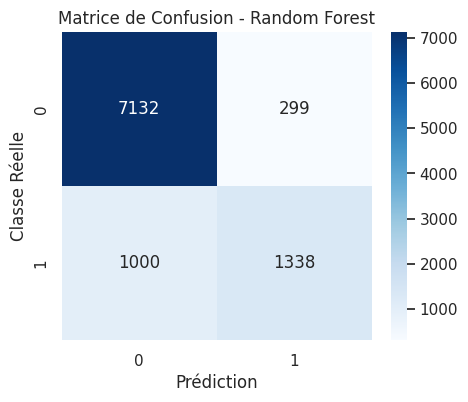

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Séparation Train / Test
X_cls = df_cleaned_prepared.drop(columns=['income', 'cluster'], errors='ignore')
y_cls = df_cleaned_prepared['income']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# 2. Entraînement et comparaison de plusieurs modèles
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Arbre de Décision': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred))
    if auc:
        print(f"ROC-AUC Score : {auc:.4f}\n")
    results[name] = model

# 3. Visualisation de la matrice de confusion pour le meilleur modèle (ex: Random Forest)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, results['Random Forest'].predict(X_test)),
            annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion - Random Forest')
plt.xlabel('Prédiction')
plt.ylabel('Classe Réelle')
plt.show()